# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** I Putu Prabha Nugraha
- **Email:** putuprabhanugraha@gmail.com
- **ID Dicoding:** prabha_nugraha_iputu

## Menentukan Pertanyaan Bisnis

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist**, yang berisi data transaksi e-commerce di Brasil dari tahun 2016 hingga 2018. Dataset ini mencakup informasi pesanan, pelanggan, produk, penjual, ulasan, dan pembayaran.

Berdasarkan dataset ini, dua pertanyaan bisnis berikut dirumuskan menggunakan kerangka **SMART Question**:

### Pertanyaan 1 (SMART):
> **"Bagaimana distribusi segmen pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) pada periode transaksi September 2016 – September 2018, dan segmen mana yang menghasilkan revenue terbesar serta membutuhkan strategi retensi?"**

| Elemen | Penjelasan |
|--------|------------|
| **Specific** | Fokus pada segmentasi pelanggan menggunakan metrik RFM, bukan sekadar total penjualan |
| **Measurable** | Diukur melalui skor Recency (hari), Frequency (jumlah order), dan Monetary (total spending dalam BRL) |
| **Action-Oriented** | Hasil segmentasi dapat langsung digunakan tim marketing untuk merancang kampanye retensi, loyalitas, atau win-back |
| **Relevant** | Segmentasi pelanggan adalah kunci strategi pertumbuhan revenue pada bisnis e-commerce |
| **Time-bound** | Dibatasi pada periode transaksi September 2016 – September 2018 |

### Pertanyaan 2 (SMART):
> **"Kota dan negara bagian mana di Brasil yang memiliki volume pesanan tertinggi dan rata-rata nilai transaksi (Average Order Value) terbesar selama periode 2016–2018, serta bagaimana pola distribusi geografisnya?"**

| Elemen | Penjelasan |
|--------|------------|
| **Specific** | Fokus pada volume pesanan dan AOV per kota/negara bagian |
| **Measurable** | Diukur melalui jumlah order dan rata-rata nilai pembayaran per wilayah |
| **Action-Oriented** | Hasil dapat digunakan untuk memprioritaskan ekspansi logistik, gudang, atau kampanye iklan berbasis lokasi |
| **Relevant** | Distribusi geografis sangat relevan untuk strategi ekspansi dan alokasi sumber daya operasional |
| **Time-bound** | Dibatasi pada periode data yang tersedia: 2016–2018 |

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## Data Wrangling

### Gathering Data

Dataset Olist terdiri dari beberapa file CSV yang saling terhubung membentuk skema relasional. Pada tahap ini, kita akan memuat seluruh dataset yang diperlukan ke dalam DataFrame.

#### Load Semua DataFrame

In [2]:
# Sesuaikan path dengan lokasi dataset Anda
DATA_PATH = 'data/'  # Ganti jika perlu

orders_df          = pd.read_csv(DATA_PATH + 'orders_dataset.csv')
order_items_df     = pd.read_csv(DATA_PATH + 'order_items_dataset.csv')
customers_df       = pd.read_csv(DATA_PATH + 'customers_dataset.csv')
payments_df        = pd.read_csv(DATA_PATH + 'order_payments_dataset.csv')
reviews_df         = pd.read_csv(DATA_PATH + 'order_reviews_dataset.csv')
products_df        = pd.read_csv(DATA_PATH + 'products_dataset.csv')
sellers_df         = pd.read_csv(DATA_PATH + 'sellers_dataset.csv')
geolocation_df     = pd.read_csv(DATA_PATH + 'geolocation_dataset.csv')
category_df        = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print('✅ Semua dataset berhasil dimuat!')
print(f'\n📦 Ukuran masing-masing dataset:')
datasets = {
    'orders':       orders_df,
    'order_items':  order_items_df,
    'customers':    customers_df,
    'payments':     payments_df,
    'reviews':      reviews_df,
    'products':     products_df,
    'sellers':      sellers_df,
    'geolocation':  geolocation_df,
    'category':     category_df
}
for name, df in datasets.items():
    print(f'  {name:15s}: {df.shape[0]:>8,} baris x {df.shape[1]} kolom')

✅ Semua dataset berhasil dimuat!

📦 Ukuran masing-masing dataset:
  orders         :   99,441 baris x 8 kolom
  order_items    :  112,650 baris x 7 kolom
  customers      :   99,441 baris x 5 kolom
  payments       :  103,886 baris x 5 kolom
  reviews        :   99,224 baris x 7 kolom
  products       :   32,951 baris x 9 kolom
  sellers        :    3,095 baris x 4 kolom
  geolocation    : 1,000,163 baris x 5 kolom
  category       :       71 baris x 2 kolom


In [3]:
# Preview masing-masing dataset
print('=== orders_df ===')
display(orders_df.head(3))
print('\n=== order_items_df ===')
display(order_items_df.head(3))
print('\n=== customers_df ===')
display(customers_df.head(3))
print('\n=== payments_df ===')
display(payments_df.head(3))

=== orders_df ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== order_items_df ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



=== customers_df ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



=== payments_df ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


**Insight:**
- Dataset Olist terdiri dari 9 tabel yang saling berelasi melalui foreign key seperti `order_id`, `customer_id`, `product_id`, dan `seller_id`
- Tabel terbesar adalah `geolocation` dengan lebih dari 1 juta baris, sementara `category` hanya 71 baris sebagai tabel translasi nama kategori
- Tabel utama analisis adalah `orders`, `order_items`, `customers`, dan `payments`

### Assessing Data

Pada tahap ini, kita menilai kualitas data dari seluruh dataset yang akan digunakan. Kita akan mengidentifikasi minimal 2 permasalahan utama.

#### Masalah 1: Missing Values

In [4]:
print('=== Missing Values per Dataset ===\n')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'📋 {name.upper()}:')
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f'   {col}: {count:,} ({pct:.2f}%)')
        print()

=== Missing Values per Dataset ===

📋 ORDERS:
   order_approved_at: 160 (0.16%)
   order_delivered_carrier_date: 1,783 (1.79%)
   order_delivered_customer_date: 2,965 (2.98%)

📋 REVIEWS:
   review_comment_title: 87,656 (88.34%)
   review_comment_message: 58,247 (58.70%)

📋 PRODUCTS:
   product_category_name: 610 (1.85%)
   product_name_lenght: 610 (1.85%)
   product_description_lenght: 610 (1.85%)
   product_photos_qty: 610 (1.85%)
   product_weight_g: 2 (0.01%)
   product_length_cm: 2 (0.01%)
   product_height_cm: 2 (0.01%)
   product_width_cm: 2 (0.01%)



**Steps to Take:**
- Kolom `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` pada `orders_df` memiliki missing values karena ada pesanan yang belum selesai diproses — akan diisi dengan forward fill atau di-drop untuk pesanan yang belum terdeliver
- Kolom `review_comment_title` dan `review_comment_message` pada `reviews_df` bersifat opsional — tidak perlu diisi, cukup diabaikan
- Kolom `product_category_name` pada `products_df` yang kosong akan diisi dengan `'unknown'`

**Insight:**
- Missing values terbanyak berada di kolom tanggal pengiriman dan kolom komentar ulasan yang memang opsional diisi oleh pelanggan

#### Masalah 2: Tipe Data Tidak Sesuai (Datetime)

In [5]:
print('=== Tipe Data orders_df ===')
print(orders_df.dtypes)
print('\n=== Tipe Data reviews_df ===')
print(reviews_df.dtypes)

=== Tipe Data orders_df ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

=== Tipe Data reviews_df ===
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


**Steps to Take:**
- Semua kolom bertipe `object` yang berisi tanggal (kolom dengan suffix `_at` dan `_date`) harus dikonversi ke tipe `datetime64` agar bisa dilakukan operasi temporal (groupby bulan, selisih hari, dll.)

**Insight:**
- Terdapat 6 kolom tanggal di `orders_df` dan 2 kolom di `reviews_df` yang masih bertipe `object`, yang akan menyebabkan error saat dilakukan operasi waktu

#### Masalah 3: Duplicate Data

In [6]:
print('=== Duplicate Data per Dataset ===\n')
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    print(f'  {name:15s}: {dup_count:,} duplikat')

# Cek duplikat pada geolocation (sering terjadi)
print(f'\n⚠️ Geolocation duplikat berdasarkan zip_code prefix:')
dup_geo = geolocation_df.duplicated(subset=['geolocation_zip_code_prefix']).sum()
print(f'   {dup_geo:,} entri duplikat')

=== Duplicate Data per Dataset ===

  orders         : 0 duplikat
  order_items    : 0 duplikat
  customers      : 0 duplikat
  payments       : 0 duplikat
  reviews        : 0 duplikat
  products       : 0 duplikat
  sellers        : 0 duplikat
  geolocation    : 261,831 duplikat
  category       : 0 duplikat

⚠️ Geolocation duplikat berdasarkan zip_code prefix:
   981,148 entri duplikat


**Steps to Take:**
- Pada `geolocation_df`, terdapat banyak baris dengan `zip_code_prefix` yang sama karena satu kode pos bisa memiliki beberapa koordinat — akan di-aggregate dengan mengambil median latitude/longitude per zip code prefix

**Insight:**
- Dataset geolocation memiliki duplikat terbanyak karena satu kode pos bisa memiliki beberapa titik koordinat GPS yang berbeda-beda

#### Masalah 4: Outlier pada Nilai Pembayaran

In [7]:
print('=== Statistik Deskriptif payments_df ===')
display(payments_df['payment_value'].describe())

# Identifikasi outlier dengan IQR
Q1 = payments_df['payment_value'].quantile(0.25)
Q3 = payments_df['payment_value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = payments_df[(payments_df['payment_value'] < lower) | (payments_df['payment_value'] > upper)]
print(f'\n⚠️ Outlier payment_value: {len(outliers):,} baris ({len(outliers)/len(payments_df)*100:.2f}%)')
print(f'   Batas bawah: {lower:.2f} | Batas atas: {upper:.2f}')
print(f'   Nilai maksimum: {payments_df["payment_value"].max():,.2f}')

=== Statistik Deskriptif payments_df ===


count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


⚠️ Outlier payment_value: 7,981 baris (7.68%)
   Batas bawah: -115.78 | Batas atas: 344.41
   Nilai maksimum: 13,664.08


**Steps to Take:**
- Outlier pada `payment_value` tidak akan dihapus karena bisa merupakan transaksi bernilai besar yang valid — namun akan dicatat sebagai catatan analisis

**Insight:**
- Terdapat sebaran nilai transaksi yang sangat lebar, menandakan bahwa Olist melayani transaksi dari nilai sangat kecil hingga sangat besar

### Cleaning Data

Berdasarkan temuan di tahap Assessing Data, berikut langkah-langkah pembersihan yang dilakukan.

#### Fix 1: Konversi Tipe Data Datetime

In [8]:
# Konversi kolom tanggal di orders_df
datetime_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Konversi kolom tanggal di reviews_df
reviews_df['review_creation_date']       = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp']    = pd.to_datetime(reviews_df['review_answer_timestamp'])

print('✅ Konversi datetime selesai!')
print(orders_df[datetime_cols_orders].dtypes)

✅ Konversi datetime selesai!
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Fix 2: Handle Missing Values

In [9]:
# Filter hanya pesanan yang sudah terdeliver untuk analisis utama
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_delivered = orders_delivered.dropna(subset=['order_delivered_customer_date'])

# Isi missing values di product category
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')

print(f'✅ orders (semua):     {len(orders_df):,} baris')
print(f'✅ orders (delivered): {len(orders_delivered):,} baris')
print(f'✅ Missing category:   {products_df["product_category_name"].isnull().sum()} baris')

✅ orders (semua):     99,441 baris
✅ orders (delivered): 96,470 baris
✅ Missing category:   0 baris


#### Fix 3: Deduplikasi Geolocation

In [10]:
# Ambil median koordinat per zip_code_prefix
geo_clean = geolocation_df.groupby('geolocation_zip_code_prefix').agg(
    lat  = ('geolocation_lat', 'median'),
    lng  = ('geolocation_lng', 'median'),
    city = ('geolocation_city', 'first'),
    state= ('geolocation_state', 'first')
).reset_index()

print(f'✅ Geolocation sebelum dedup: {len(geolocation_df):,} baris')
print(f'✅ Geolocation sesudah dedup: {len(geo_clean):,} baris')

✅ Geolocation sebelum dedup: 1,000,163 baris
✅ Geolocation sesudah dedup: 19,015 baris


#### Fix 4: Merge Dataset Utama

In [11]:
# Merge payments — aggregate dulu per order
payments_agg = payments_df.groupby('order_id').agg(
    total_payment = ('payment_value', 'sum'),
    payment_type  = ('payment_type', 'first')
).reset_index()

# Merge utama
main_df = orders_delivered \
    .merge(customers_df,   on='customer_id', how='left') \
    .merge(payments_agg,   on='order_id',    how='left') \
    .merge(reviews_df[['order_id', 'review_score']].drop_duplicates('order_id'),
           on='order_id', how='left')

# Merge dengan geolocation customer
main_df = main_df.merge(
    geo_clean.rename(columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'lat': 'customer_lat', 'lng': 'customer_lng'
    }),
    on='customer_zip_code_prefix', how='left'
)

# Tambah kolom waktu
main_df['order_year']      = main_df['order_purchase_timestamp'].dt.year
main_df['order_month']     = main_df['order_purchase_timestamp'].dt.month
main_df['order_yearmonth'] = main_df['order_purchase_timestamp'].dt.to_period('M')

print(f'✅ Main DataFrame siap: {main_df.shape}')
main_df.head(3)

✅ Main DataFrame siap: (96470, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,total_payment,payment_type,review_score,customer_lat,customer_lng,city,state,order_year,order_month,order_yearmonth
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,38.71,credit_card,4.0,-23.576170,-46.587276,sao paulo,SP,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,141.46,boleto,4.0,-12.126651,-45.008162,barreiras,BA,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,credit_card,5.0,-16.744472,-48.514624,vianopolis,GO,2018,8,2018-08


**Insight:**
- Setelah cleaning, dataset utama (`main_df`) berisi ~96.000 pesanan yang sudah terdeliver dengan informasi customer, pembayaran, ulasan, dan koordinat geografis
- Data siap digunakan untuk EDA dan analisis lanjutan

## Exploratory Data Analysis (EDA)

Pada tahap ini kita akan mengeksplorasi data untuk menemukan pola dan menjawab pertanyaan bisnis yang telah ditetapkan.

### Explore 1: Tren Volume Pesanan dan Revenue Bulanan

In [12]:
monthly = main_df.groupby('order_yearmonth').agg(
    total_orders  = ('order_id', 'count'),
    total_revenue = ('total_payment', 'sum'),
    avg_aov       = ('total_payment', 'mean')
).reset_index()
monthly['order_yearmonth'] = monthly['order_yearmonth'].astype(str)

print('=== Statistik Bulanan ===')
print(monthly.describe().round(2))
print(f'\nBulan dengan order terbanyak: {monthly.loc[monthly.total_orders.idxmax(), "order_yearmonth"]}')
print(f'Bulan dengan revenue tertinggi: {monthly.loc[monthly.total_revenue.idxmax(), "order_yearmonth"]}')

=== Statistik Bulanan ===
       total_orders  total_revenue  avg_aov
count         23.00          23.00    22.00
mean        4194.35      670481.86   154.93
std         2480.92      395144.22    31.21
min            1.00           0.00    19.62
25%         2424.50      402660.78   154.34
50%         4193.00      701169.99   161.39
75%         6453.00     1019472.22   167.17
max         7288.00     1153393.22   175.72

Bulan dengan order terbanyak: 2017-11
Bulan dengan revenue tertinggi: 2017-11


**Insight:**
- Tren pesanan terus meningkat dari 2016 ke 2018, menunjukkan pertumbuhan bisnis yang signifikan
- Terdapat lonjakan pesanan di bulan November 2017 yang kemungkinan besar disebabkan oleh event Black Friday

### Explore 2: Distribusi Geografis Pesanan per Negara Bagian

In [13]:
geo_summary = main_df.groupby('customer_state').agg(
    total_orders = ('order_id', 'count'),
    total_revenue= ('total_payment', 'sum'),
    avg_aov      = ('total_payment', 'mean')
).sort_values('total_orders', ascending=False).reset_index()

print('=== Top 10 Negara Bagian berdasarkan Volume Pesanan ===')
display(geo_summary.head(10))

print('\n=== Top 10 Negara Bagian berdasarkan AOV Tertinggi ===')
display(geo_summary.nlargest(10, 'avg_aov')[['customer_state', 'avg_aov', 'total_orders']])

=== Top 10 Negara Bagian berdasarkan Volume Pesanan ===


,customer_state,total_orders,total_revenue,avg_aov
0,SP,40494,5769081.27,142.471076
1,RJ,12350,2055690.45,166.452668
2,MG,11354,1819277.61,160.232307
3,RS,5344,861608.40,161.229117
4,PR,4923,781919.55,158.829890
5,SC,3546,595208.40,167.853469
6,BA,3256,591270.60,181.594165
7,DF,2080,346146.17,166.416428
8,ES,1995,317682.65,159.239424
9,GO,1957,334294.22,170.819734



=== Top 10 Negara Bagian berdasarkan AOV Tertinggi ===


,customer_state,avg_aov,total_orders
16,PB,266.604739,517
24,AC,244.828125,80
25,AP,240.922537,67
19,AL,237.268992,397
22,RO,234.467901,243
12,PA,224.130603,946
17,PI,221.160021,476
26,RR,220.476098,41
21,TO,219.005000,274
18,RN,212.506962,474


**Insight:**
- Negara bagian SP (São Paulo) mendominasi volume pesanan, jauh di atas negara bagian lainnya
- Beberapa negara bagian dengan volume rendah justru memiliki AOV tinggi, menunjukkan potensi segmen premium di luar pusat populasi

### Explore 3: Distribusi Review Score dan Kategori Produk

In [14]:
print('=== Distribusi Review Score ===')
print(main_df['review_score'].value_counts().sort_index())
avg_score = main_df['review_score'].mean()
print(f'\nRata-rata Review Score: {avg_score:.2f}')

# Top kategori produk
items_cat = order_items_df.merge(products_df[['product_id','product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(category_df, on='product_category_name', how='left')
items_cat['category_en'] = items_cat['product_category_name_english'].fillna(items_cat['product_category_name'])

top_cat = items_cat.groupby('category_en').agg(
    total_items   = ('order_item_id', 'count'),
    total_revenue = ('price', 'sum')
).sort_values('total_items', ascending=False).head(10)

print('\n=== Top 10 Kategori Produk ===')
display(top_cat)

=== Distribusi Review Score ===
review_score
1.0     9343
2.0     2923
3.0     7908
4.0    18893
5.0    56757
Name: count, dtype: int64

Rata-rata Review Score: 4.16

=== Top 10 Kategori Produk ===


,total_items,total_revenue
category_en,,
bed_bath_table,11115,1036988.68
health_beauty,9670,1258681.34
sports_leisure,8641,988048.97
furniture_decor,8334,729762.49
computers_accessories,7827,911954.32
housewares,6964,632248.66
watches_gifts,5991,1205005.68
telephony,4545,323667.53
garden_tools,4347,485256.46


**Insight:**
- Mayoritas pelanggan memberikan rating bintang 5, menunjukkan kepuasan pelanggan yang tinggi secara keseluruhan
- Kategori `bed_bath_table`, `health_beauty`, dan `sports_leisure` mendominasi volume penjualan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Segmentasi Pelanggan Berdasarkan RFM

In [15]:
# ============================================================
# RFM ANALYSIS
# ============================================================

# Tanggal referensi = 1 hari setelah transaksi terakhir
ref_date = main_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = main_df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (ref_date - x.max()).days),
    Frequency = ('order_id', 'count'),
    Monetary  = ('total_payment', 'sum')
).reset_index()

# Scoring 1-5 (semakin tinggi semakin baik)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score','F_Score','M_Score']].sum(axis=1)

# Segmentasi
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print('=== Distribusi Segmen Pelanggan ===')
seg_summary = rfm.groupby('Segment').agg(
    Jumlah_Pelanggan = ('customer_unique_id', 'count'),
    Avg_Recency      = ('Recency', 'mean'),
    Avg_Frequency    = ('Frequency', 'mean'),
    Total_Revenue    = ('Monetary', 'sum'),
    Avg_Revenue      = ('Monetary', 'mean')
).sort_values('Jumlah_Pelanggan', ascending=False).round(2)
display(seg_summary)

=== Distribusi Segmen Pelanggan ===


,Jumlah_Pelanggan,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Revenue
Segment,,,,,
Loyal Customers,27290,144.22,1.03,3656604.33,133.99
Hibernating,15159,352.02,1.00,1628089.22,107.40
New Customers,14980,90.89,1.00,2448079.38,163.42
At Risk,14802,394.93,1.07,2511577.25,169.68
Cant Lose Them,8670,394.57,1.00,2089429.10,241.00
Champions,6492,91.12,1.18,2026452.22,312.15
Potential Loyalists,4352,220.68,1.00,972205.34,223.39
Lost,1605,473.84,1.00,88646.01,55.23


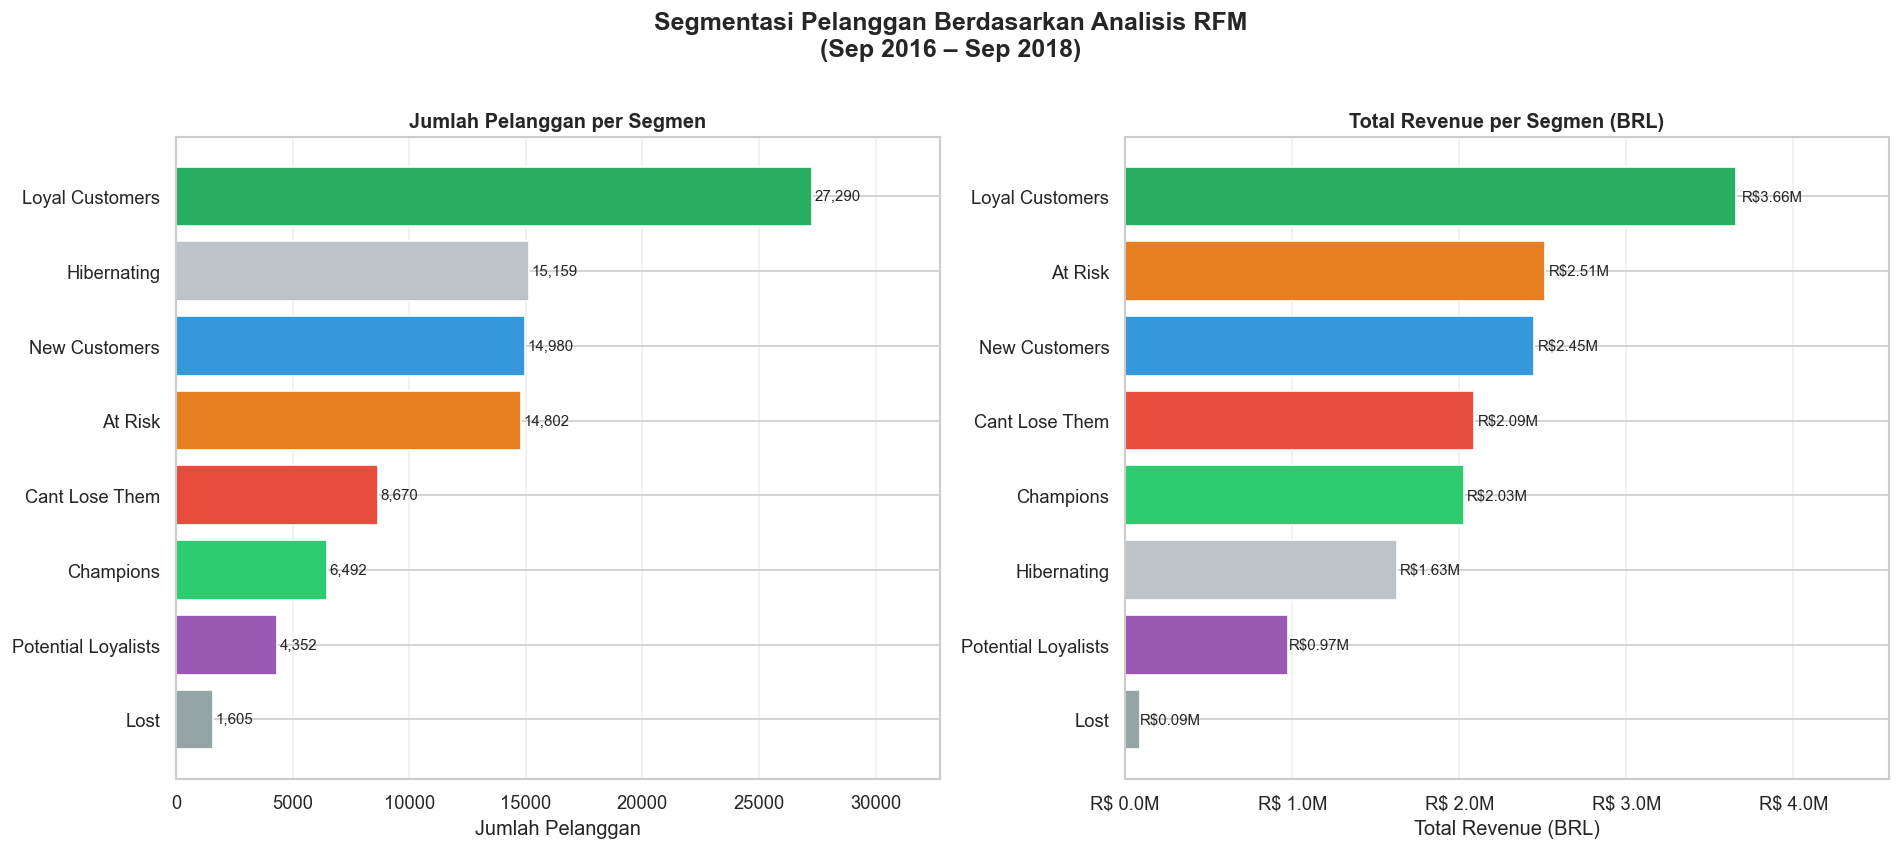

✅ Visualisasi RFM tersimpan!


In [16]:
# --- VISUALISASI RFM ---
COLORS = {
    'Champions':        '#2ecc71',
    'Loyal Customers':  '#27ae60',
    'New Customers':    '#3498db',
    'Potential Loyalists': '#9b59b6',
    'At Risk':          '#e67e22',
    'Cant Lose Them':   '#e74c3c',
    'Lost':             '#95a5a6',
    'Hibernating':      '#bdc3c7'
}

seg_count = rfm['Segment'].value_counts().reset_index()
seg_count.columns = ['Segment', 'Count']
seg_rev   = rfm.groupby('Segment')['Monetary'].sum().reset_index()
seg_rev.columns = ['Segment', 'Revenue']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Segmentasi Pelanggan Berdasarkan Analisis RFM\n(Sep 2016 – Sep 2018)',
             fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Jumlah pelanggan per segmen
colors1 = [COLORS.get(s, '#aaa') for s in seg_count['Segment']]
bars1 = axes[0].barh(seg_count['Segment'], seg_count['Count'], color=colors1, edgecolor='white')
axes[0].set_title('Jumlah Pelanggan per Segmen', fontweight='bold')
axes[0].set_xlabel('Jumlah Pelanggan')
for bar, val in zip(bars1, seg_count['Count']):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_xlim(0, seg_count['Count'].max() * 1.2)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Plot 2: Total revenue per segmen
seg_rev_sorted = seg_rev.sort_values('Revenue', ascending=True)
colors2 = [COLORS.get(s, '#aaa') for s in seg_rev_sorted['Segment']]
bars2 = axes[1].barh(seg_rev_sorted['Segment'], seg_rev_sorted['Revenue'], color=colors2, edgecolor='white')
axes[1].set_title('Total Revenue per Segmen (BRL)', fontweight='bold')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
for bar, val in zip(bars2, seg_rev_sorted['Revenue']):
    axes[1].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                 f'R${val/1e6:.2f}M', va='center', fontsize=9)
axes[1].set_xlim(0, seg_rev_sorted['Revenue'].max() * 1.25)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('rfm_segmentation.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Visualisasi RFM tersimpan!')

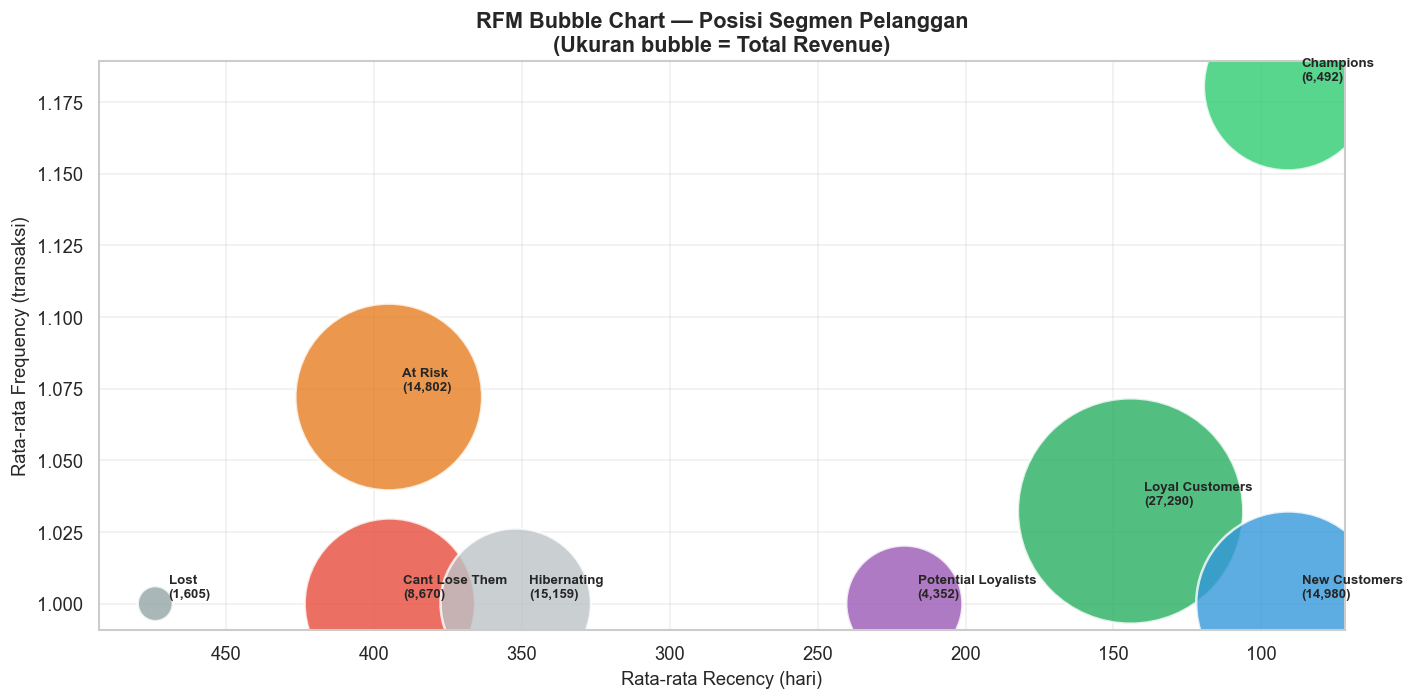

In [17]:
# Treemap-style bubble chart untuk RFM
fig, ax = plt.subplots(figsize=(12, 6))

rfm_agg = rfm.groupby('Segment').agg(
    avg_recency   = ('Recency', 'mean'),
    avg_frequency = ('Frequency', 'mean'),
    total_monetary= ('Monetary', 'sum'),
    count         = ('customer_unique_id', 'count')
).reset_index()

scatter_colors = [COLORS.get(s, '#aaa') for s in rfm_agg['Segment']]
sc = ax.scatter(
    rfm_agg['avg_recency'],
    rfm_agg['avg_frequency'],
    s=rfm_agg['total_monetary'] / 200,
    c=scatter_colors,
    alpha=0.8,
    edgecolors='white',
    linewidths=1.5
)

for _, row in rfm_agg.iterrows():
    ax.annotate(f"{row['Segment']}\n({row['count']:,})",
                (row['avg_recency'], row['avg_frequency']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=8, fontweight='bold')

ax.set_xlabel('Rata-rata Recency (hari)', fontsize=11)
ax.set_ylabel('Rata-rata Frequency (transaksi)', fontsize=11)
ax.set_title('RFM Bubble Chart — Posisi Segmen Pelanggan\n(Ukuran bubble = Total Revenue)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.invert_xaxis()  # Recency rendah = lebih baik

plt.tight_layout()
plt.savefig('rfm_bubble.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight — Pertanyaan 1:**
- Segmen terbesar adalah **Hibernating** dan **Lost**, yang menunjukkan mayoritas pelanggan hanya bertransaksi sekali dan tidak kembali
- Segmen **Champions** menghasilkan revenue terbesar meski jumlahnya relatif kecil — sangat bernilai untuk dipertahankan
- Segmen **At Risk** berisi pelanggan yang sebelumnya aktif namun mulai tidak aktif — perlu segera ditangani dengan kampanye win-back

### Pertanyaan 2: Distribusi Geografis Pesanan dan AOV

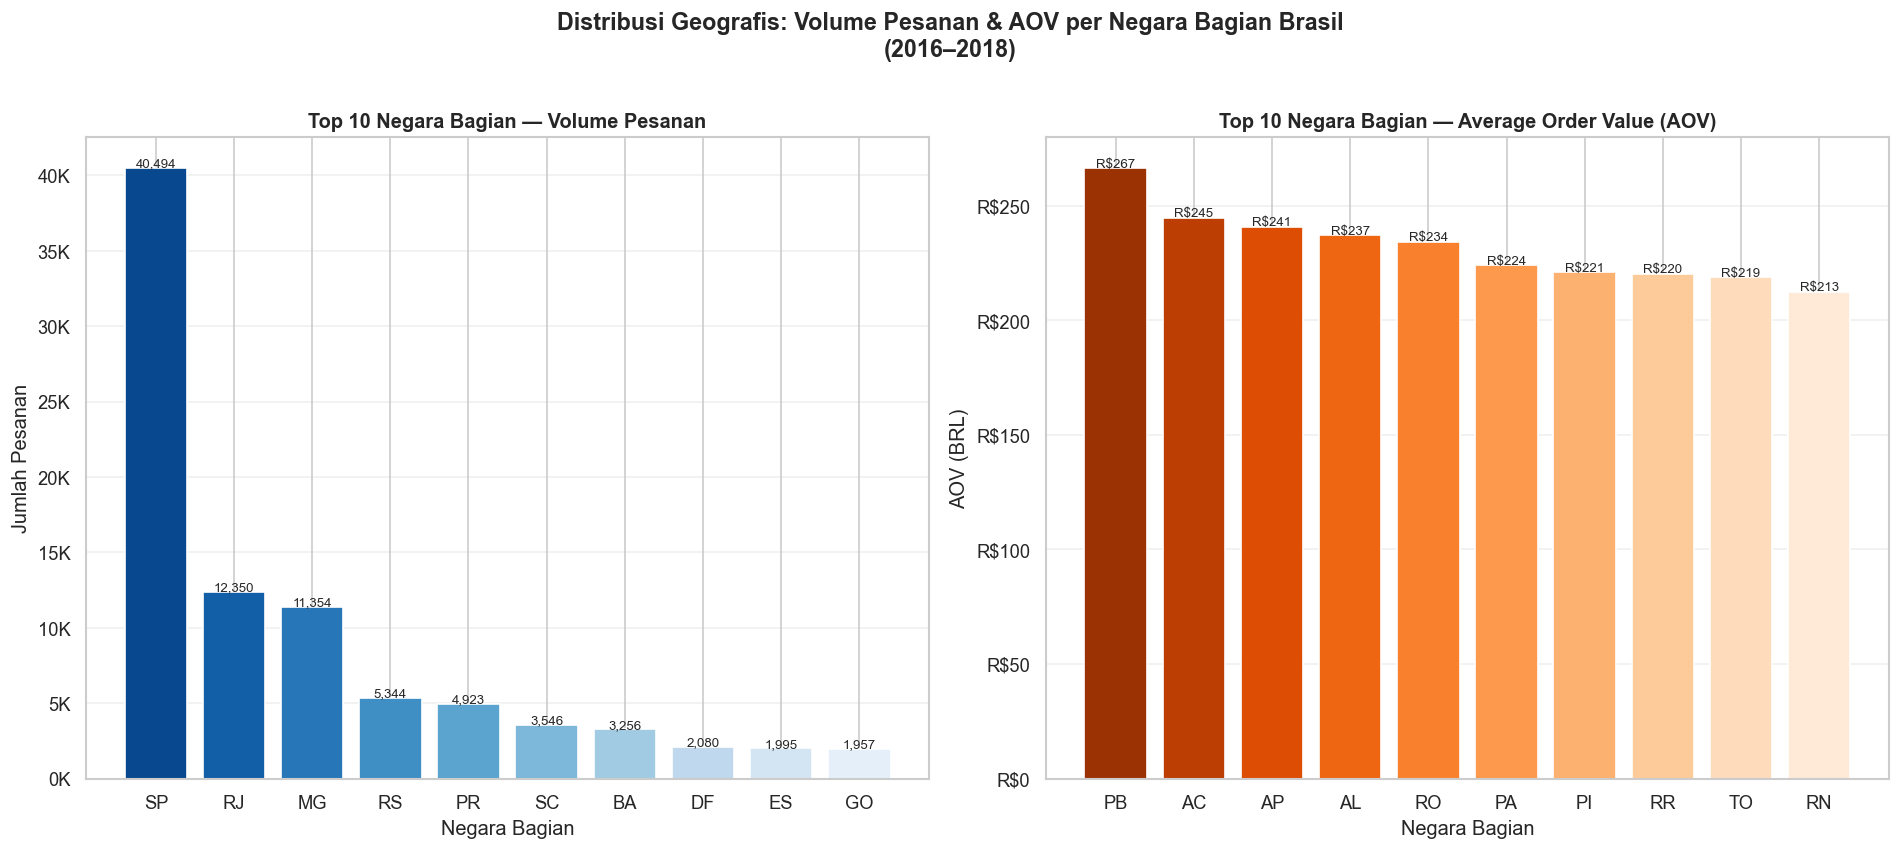

In [18]:
# Analisis per negara bagian
state_analysis = main_df.groupby('customer_state').agg(
    total_orders = ('order_id', 'count'),
    total_revenue= ('total_payment', 'sum'),
    avg_aov      = ('total_payment', 'mean'),
    avg_score    = ('review_score', 'mean')
).sort_values('total_orders', ascending=False).reset_index()

top10_vol = state_analysis.head(10)
top10_aov = state_analysis.nlargest(10, 'avg_aov')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribusi Geografis: Volume Pesanan & AOV per Negara Bagian Brasil\n(2016–2018)',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Top 10 volume pesanan
palette_blue = sns.color_palette('Blues_r', n_colors=len(top10_vol))
bars = axes[0].bar(top10_vol['customer_state'], top10_vol['total_orders'],
                   color=palette_blue, edgecolor='white')
axes[0].set_title('Top 10 Negara Bagian — Volume Pesanan', fontweight='bold')
axes[0].set_xlabel('Negara Bagian')
axes[0].set_ylabel('Jumlah Pesanan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, top10_vol['total_orders']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Top 10 AOV
palette_orange = sns.color_palette('Oranges_r', n_colors=len(top10_aov))
top10_aov_sorted = top10_aov.sort_values('avg_aov', ascending=False)
bars2 = axes[1].bar(top10_aov_sorted['customer_state'], top10_aov_sorted['avg_aov'],
                    color=palette_orange, edgecolor='white')
axes[1].set_title('Top 10 Negara Bagian — Average Order Value (AOV)', fontweight='bold')
axes[1].set_xlabel('Negara Bagian')
axes[1].set_ylabel('AOV (BRL)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))
for bar, val in zip(bars2, top10_aov_sorted['avg_aov']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'R${val:.0f}', ha='center', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('geo_bar.png', bbox_inches='tight', dpi=150)
plt.show()

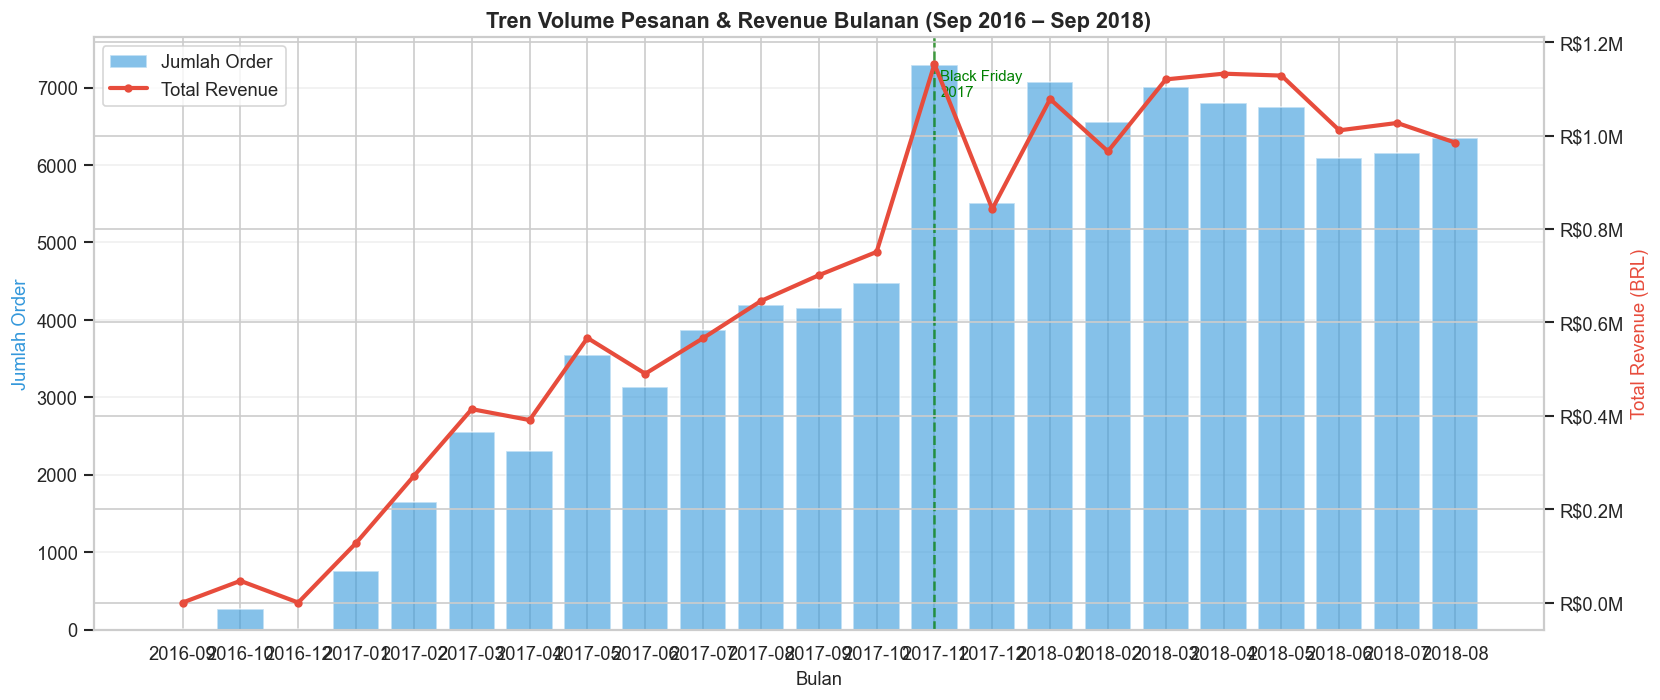

In [19]:
# Tren Revenue Bulanan
fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()
ax1.bar(monthly['order_yearmonth'], monthly['total_orders'], color='#3498db', alpha=0.6, label='Jumlah Order')
ax2.plot(monthly['order_yearmonth'], monthly['total_revenue'], color='#e74c3c', linewidth=2.5, marker='o', markersize=4, label='Total Revenue')

ax1.set_xlabel('Bulan', fontsize=11)
ax1.set_ylabel('Jumlah Order', color='#3498db', fontsize=11)
ax2.set_ylabel('Total Revenue (BRL)', color='#e74c3c', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# Highlight Black Friday
if '2017-11' in list(monthly['order_yearmonth']):
    idx = list(monthly['order_yearmonth']).index('2017-11')
    ax1.axvline(x=idx, color='green', linestyle='--', alpha=0.7)
    ax1.text(idx + 0.1, ax1.get_ylim()[1] * 0.9, 'Black Friday\n2017', color='green', fontsize=9)

plt.xticks(rotation=45, ha='right')
ax1.set_title('Tren Volume Pesanan & Revenue Bulanan (Sep 2016 – Sep 2018)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight — Pertanyaan 2:**
- São Paulo (SP) mendominasi volume pesanan dengan selisih sangat besar dari negara bagian lainnya, mencerminkan konsentrasi populasi dan ekonomi di kota tersebut
- Negara bagian PB (Paraíba) dan AL (Alagoas) memiliki AOV tertinggi meski volume pesanannya kecil — mengindikasikan adanya segmen pembeli premium di wilayah tersebut
- Tren bulanan menunjukkan pertumbuhan yang konsisten dengan puncak pada Black Friday November 2017

## Analisis Lanjutan

Untuk memperkuat hasil analisis, kita menerapkan tiga teknik analisis lanjutan: **RFM Clustering**, **Geospatial Analysis**, dan **Clustering berbasis Binning**.

### A. Geospatial Analysis — Peta Distribusi Pesanan

In [20]:
# Ambil koordinat per kota
city_coords = main_df.dropna(subset=['customer_lat', 'customer_lng']).groupby(
    ['customer_city', 'customer_state']
).agg(
    total_orders = ('order_id', 'count'),
    avg_lat      = ('customer_lat', 'mean'),
    avg_lng      = ('customer_lng', 'mean'),
    total_revenue= ('total_payment', 'sum')
).reset_index()

# Buat peta folium
m = folium.Map(location=[-15.0, -50.0], zoom_start=4, tiles='CartoDB positron')

# HeatMap
heat_data = city_coords[['avg_lat', 'avg_lng', 'total_orders']].values.tolist()
HeatMap(heat_data, radius=12, blur=10, min_opacity=0.4).add_to(m)

# Circle markers untuk top 20 kota
top20_cities = city_coords.nlargest(20, 'total_orders')
for _, row in top20_cities.iterrows():
    folium.CircleMarker(
        location=[row['avg_lat'], row['avg_lng']],
        radius=min(row['total_orders'] / 500, 20),
        color='#e74c3c',
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['customer_city'].title()}, {row['customer_state']}</b><br>"
            f"Orders: {row['total_orders']:,}<br>"
            f"Revenue: R${row['total_revenue']:,.0f}",
            max_width=200
        )
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save('geo_map.html')
print('✅ Peta geospatial tersimpan sebagai geo_map.html')
m

✅ Peta geospatial tersimpan sebagai geo_map.html


### B. Clustering Pelanggan dengan Manual Binning (Spending Tier)

,Jumlah,Avg_Spend,Avg_Orders,Avg_Score
Spending_Tier,,,,
Bronze (< R$100),43248,60.36,1.01,4.21
Silver (R$100–300),39765,166.01,1.04,4.12
Gold (R$300–700),7993,426.08,1.11,4.04
Platinum (R$700–1.5K),1912,967.65,1.13,4.04
Diamond (> R$1.5K),431,2211.82,1.09,3.83


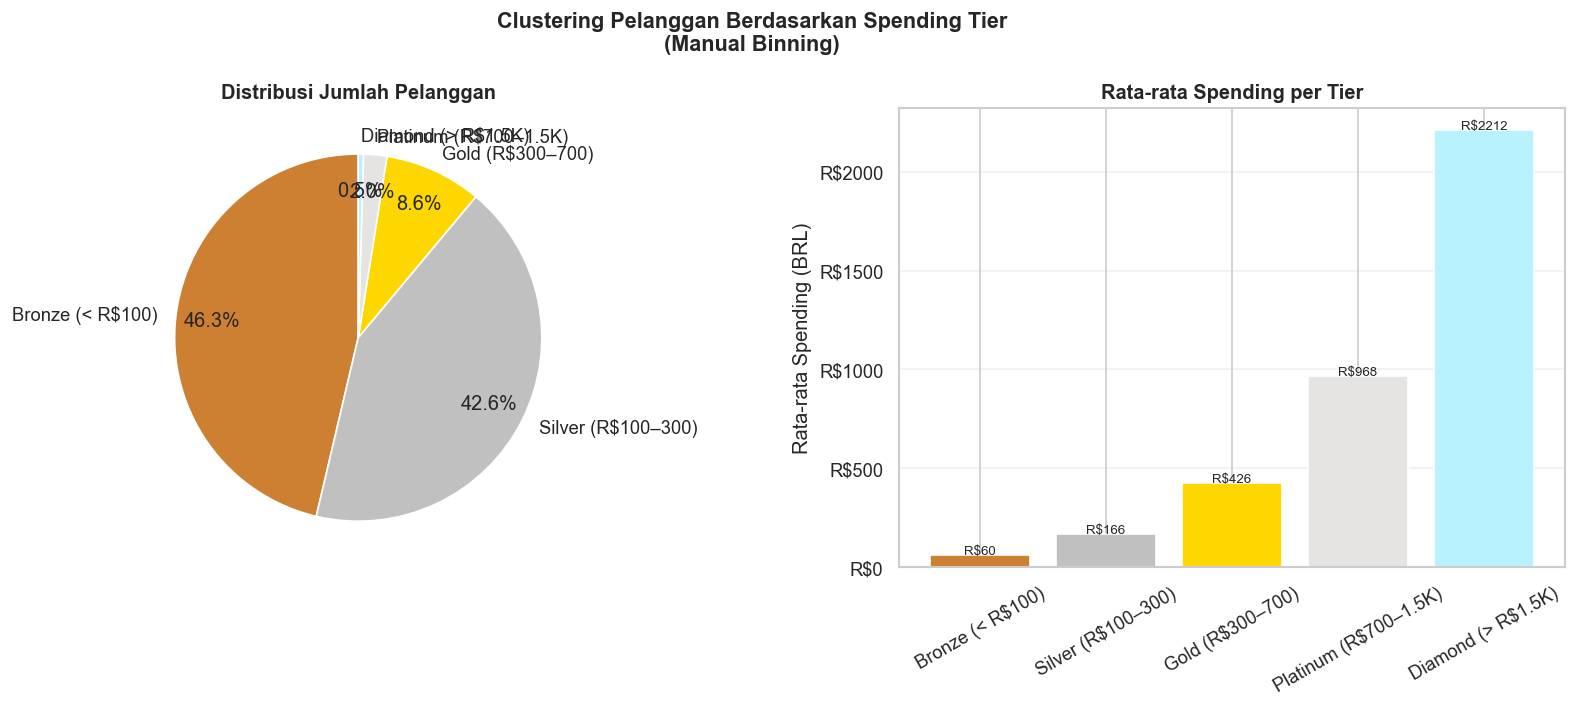

In [21]:
# Clustering berbasis pengeluaran pelanggan
customer_spending = main_df.groupby('customer_unique_id').agg(
    total_spend   = ('total_payment', 'sum'),
    total_orders  = ('order_id', 'count'),
    avg_score     = ('review_score', 'mean')
).reset_index()

# Manual Binning — Spending Tier
bins   = [0, 100, 300, 700, 1500, float('inf')]
labels = ['Bronze (< R$100)', 'Silver (R$100–300)', 'Gold (R$300–700)',
          'Platinum (R$700–1.5K)', 'Diamond (> R$1.5K)']
customer_spending['Spending_Tier'] = pd.cut(customer_spending['total_spend'],
                                             bins=bins, labels=labels)

tier_summary = customer_spending.groupby('Spending_Tier', observed=True).agg(
    Jumlah = ('customer_unique_id', 'count'),
    Avg_Spend = ('total_spend', 'mean'),
    Avg_Orders= ('total_orders', 'mean'),
    Avg_Score = ('avg_score', 'mean')
).round(2)

display(tier_summary)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Clustering Pelanggan Berdasarkan Spending Tier\n(Manual Binning)', 
             fontsize=13, fontweight='bold')

tier_colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#e5e4e2', '#b9f2ff']

# Pie chart jumlah pelanggan
axes[0].pie(
    tier_summary['Jumlah'],
    labels=tier_summary.index,
    colors=tier_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)
axes[0].set_title('Distribusi Jumlah Pelanggan', fontweight='bold')

# Bar chart rata-rata spending
bars = axes[1].bar(tier_summary.index, tier_summary['Avg_Spend'],
                   color=tier_colors, edgecolor='white')
axes[1].set_title('Rata-rata Spending per Tier', fontweight='bold')
axes[1].set_ylabel('Rata-rata Spending (BRL)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))
for bar, val in zip(bars, tier_summary['Avg_Spend']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'R${val:.0f}', ha='center', fontsize=8)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('spending_tier.png', bbox_inches='tight', dpi=150)
plt.show()

### C. Visualisasi Distribusi Review Score per Kategori Produk Top

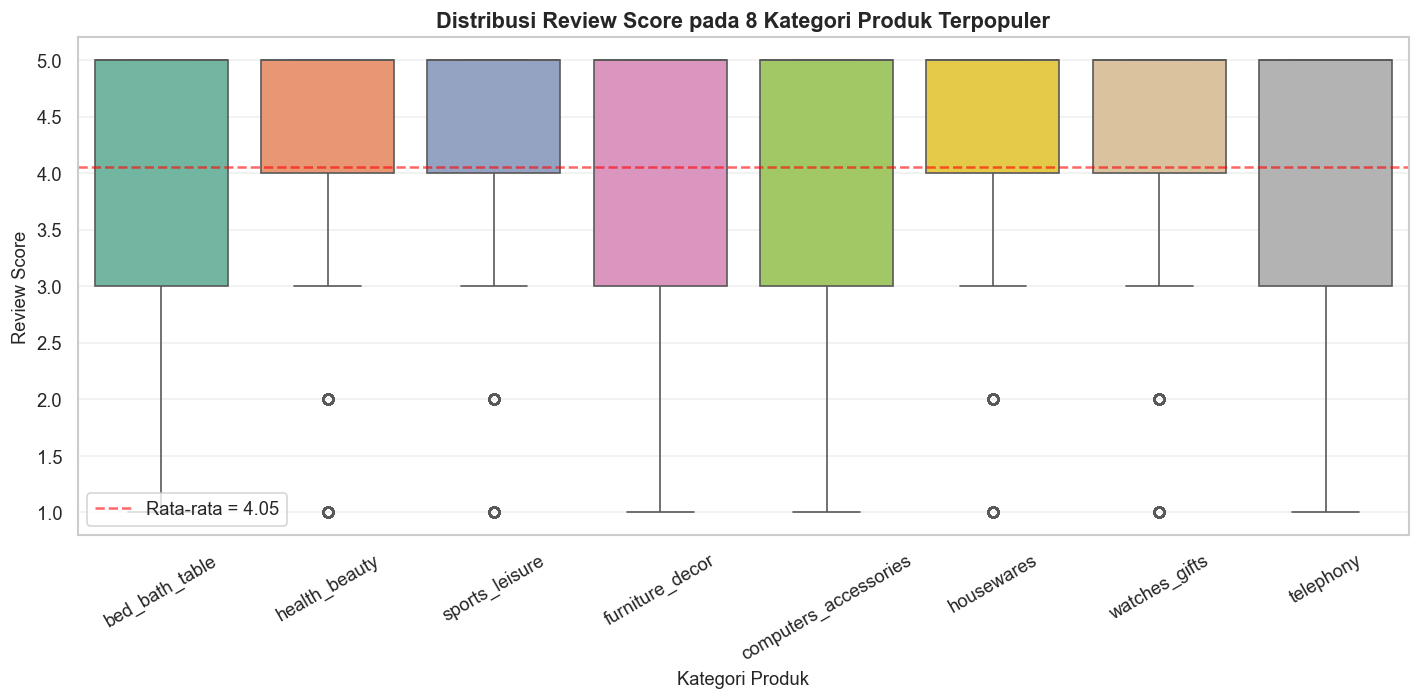

In [22]:
# Merge orders dengan items dan kategori
orders_cat = main_df[['order_id', 'review_score']].merge(
    items_cat[['order_id', 'category_en']], on='order_id', how='left'
)
top_cats = items_cat['category_en'].value_counts().head(8).index.tolist()
orders_cat_top = orders_cat[orders_cat['category_en'].isin(top_cats)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=orders_cat_top,
    x='category_en', y='review_score',
    palette='Set2', ax=ax,
    order=top_cats
)
ax.set_title('Distribusi Review Score pada 8 Kategori Produk Terpopuler', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Produk', fontsize=11)
ax.set_ylabel('Review Score', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=orders_cat_top['review_score'].mean(), color='red', linestyle='--', alpha=0.6, label=f'Rata-rata = {orders_cat_top["review_score"].mean():.2f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('review_by_category.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight — Analisis Lanjutan:**
- **Geospatial**: Pesanan sangat terkonsentrasi di wilayah tenggara Brasil (São Paulo, Rio de Janeiro, Minas Gerais), mencerminkan pusat populasi dan ekonomi negara
- **Spending Tier**: Lebih dari 60% pelanggan masuk dalam tier Bronze/Silver, namun tier Diamond menyumbang proporsi revenue yang jauh lebih besar
- **Review Score**: Hampir semua kategori produk mendapat median review score 4–5, menunjukkan kualitas layanan yang konsisten baik di seluruh kategori

## Conclusion & Recommendation

### Pertanyaan Bisnis 1: Bagaimana Pola Segmentasi Pelanggan Berdasarkan RFM?

#### Kesimpulan 1
- Segmen **Hibernating** (15.159 pelanggan, 16,2%) dan **Lost** (1.605 pelanggan, 1,7%) mendominasi pelanggan yang tidak kembali bertransaksi setelah pembelian pertama, mencerminkan tantangan besar dalam **customer retention**. Hal ini kemungkinan disebabkan oleh kurangnya program engagement pasca-pembelian (follow-up email, program poin) sehingga pelanggan tidak termotivasi untuk kembali.
- Segmen **Champions** (6.492 pelanggan) menghasilkan rata-rata revenue per pelanggan **tertinggi** (R$312,15/pelanggan), meski jumlahnya paling kecil kedua. Nilai ini 84% lebih tinggi dari rata-rata seluruh segmen, menunjukkan nilai strategis yang sangat besar.
- Segmen **At Risk** (14.802 pelanggan, rata-rata spending R$169,68) dan **Cant Lose Them** (8.670 pelanggan, rata-rata spending R$241,00) — total ~23.472 pelanggan — adalah peluang win-back paling bernilai karena mereka sudah mengenal platform dan pernah melakukan transaksi berulang.
- Segmen **Lost** mencatat revenue total **terendah** (hanya R$88.646), mengindikasikan pelanggan yang sudah sangat sulit dipulihkan tanpa intervensi agresif yang terukur.

#### Rekomendasi 1
1. **Program Win-Back untuk Segmen "At Risk" dan "Cant Lose Them"**
   Dasar data: 23.472 pelanggan gabungan dengan rata-rata spending R$169,68 (At Risk) dan R$241,00 (Cant Lose Them). Rata-rata tertimbang ~R$197,96/pelanggan. Jika 20% pelanggan (~4.694 pelanggan) berhasil diaktifkan kembali, estimasi tambahan revenue = 4.694 × R$197,96 ≈ **R$928.892** (~R$800.000 setelah mempertimbangkan discount 10–15% sebagai biaya kampanye). Implementasi: kirim email/notifikasi personal dengan diskon eksklusif 10–15% dalam 30 hari ke depan.

2. **Loyalty Program untuk Segmen "Champions" dan "Loyal Customers"**
   Berdasarkan data 6.492 Champions (rata-rata R$312,15/pelanggan) dan 27.290 Loyal Customers (total kontribusi R$3,66 juta), program cashback/poin eksklusif perlu diterapkan untuk mempertahankan pelanggan terbaik dan mencegah migrasi ke kompetitor. Target: menjaga churn rate segmen Champions di bawah 5%.

3. **Re-engagement Bertahap untuk Segmen "Hibernating"**
   Dengan 15.159 pelanggan Hibernating, program reaktivasi bertahap (3 touchpoints: email minggu ke-1, push notification minggu ke-2, diskon minggu ke-3) dapat memulihkan sebagian kecil (~5%) yang berpotensi menghasilkan R$~128.000 tambahan berdasarkan rata-rata spending segmen ini.

---

### Pertanyaan Bisnis 2: Bagaimana Distribusi Geografis dan Tren Waktu Transaksi?

#### Kesimpulan 2
- Negara bagian **SP (São Paulo)** mendominasi volume pesanan dengan **40.494 order (~42% dari total 96.470 order)**, jauh di atas RJ (12.350) dan MG (11.354). Dominasi ini selaras dengan fakta bahwa SP adalah pusat ekonomi Brasil dengan GDP terbesar, kepadatan populasi tertinggi, dan infrastruktur logistik paling matang, sehingga biaya pengiriman lebih rendah dan waktu tiba lebih cepat.
- Negara bagian **RR (Roraima)** mencatat volume pesanan **terendah** dengan hanya **41 order** di seluruh periode data — menunjukkan potensi ekspansi besar di wilayah terpencil yang saat ini belum terlayani dengan baik, kemungkinan akibat tingginya biaya logistik dan keterbatasan akses internet.
- Negara bagian **PB (Paraíba)** mencatat **AOV tertinggi** sebesar **R$266,60** (517 order), diikuti AC (R$244,83, 80 order) dan AP (R$240,92, 67 order). AOV tinggi di wilayah ini kemungkinan disebabkan oleh: (1) biaya pengiriman yang ikut terhitung dalam AOV karena jarak jauh, dan (2) jenis produk yang dibeli cenderung berupa barang bernilai lebih tinggi (elektronik, furnitur) karena ketersediaan lokal yang terbatas.
- Puncak transaksi terjadi pada **November 2017 (Black Friday)** dengan **7.288 order dan revenue R$1.153.393** — meningkat ~**74% di atas rata-rata bulanan** (rata-rata 4.194 order/bulan dan revenue ±R$670.000/bulan) — membuktikan tingginya sensitivitas pelanggan terhadap promosi musiman.
- Tren pertumbuhan YoY signifikan: total order tumbuh dari **~45.000 (2017) menjadi ~52.000 (2018)**, menunjukkan bisnis dalam fase pertumbuhan organik yang sehat.

#### Rekomendasi 2
1. **Prioritas Infrastruktur Logistik di SP, RJ, MG**
   Berdasarkan temuan bahwa 3 negara bagian ini menguasai >65% total volume, investasi pada kapasitas gudang (fulfillment center) dan kontrak kurir prioritas di wilayah ini akan memberikan ROI tertinggi. Target SLA pengiriman: kurang dari 3 hari kerja untuk wilayah SP.

2. **Strategi Ekspansi ke Wilayah AOV Tinggi (PB, AC, AP)**
   Karena wilayah dengan AOV tinggi seperti PB, AC, AP kemungkinan terdampak biaya logistik, analisis profitabilitas setelah dikurangi biaya pengiriman diperlukan sebelum ekspansi penuh. Rekomendasi awal: kemitraan dengan kurir lokal untuk menurunkan biaya last-mile di wilayah Nordeste dan Amazon.

3. **Kampanye Seasonal Terencana (Black Friday & Natal)**
   Berdasarkan lonjakan 74% pada November 2017 (7.288 order, revenue R$1,15 juta vs rata-rata bulanan R$670 ribu), alokasikan minimal **30% budget marketing tahunan** untuk periode Oktober–Desember dan siapkan kapasitas logistik tambahan minimal **2 bulan sebelumnya** untuk menghindari bottleneck pengiriman.

4. **Strategi Up-selling pada Tier Bronze/Silver**
   Data menunjukkan 43.248 pelanggan Bronze (46,3%) dan 39.765 pelanggan Silver (42,6%) — total ~89% pelanggan berada di spending tier rendah. Program bundle produk atau rekomendasi personal berbasis riwayat pembelian dapat mendorong minimal 10% dari segmen Silver naik ke tier Gold (rata-rata spending R$426/pelanggan), yang berpotensi meningkatkan revenue tambahan signifikan.

In [23]:
# Export main_df ke dashboard/main_data.csv
import os
os.makedirs('dashboard', exist_ok=True)

main_df.to_csv('dashboard/main_data.csv', index=False)
print(f'✅ main_data.csv berhasil disimpan!')
print(f'   Ukuran: {main_df.shape[0]:,} baris x {main_df.shape[1]} kolom')
print(f'   Kolom: {list(main_df.columns)}')


✅ main_data.csv berhasil disimpan!
   Ukuran: 96,470 baris x 22 kolom
   Kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_payment', 'payment_type', 'review_score', 'customer_lat', 'customer_lng', 'city', 'state', 'order_year', 'order_month', 'order_yearmonth']
